#**Evaluating Machine Learning Models for Intrusion Detection Using the NSL-KDD Dataset**



## Welcome to our Machine Learning Project!

We are a team composed of **Ahmed BENLAFQIH**, **Chinyere CUMMINGS** and **Mohamed SAÏDANE** from OCC group 1 - 4th year students.

Our aim in this project is to develop a machine learning model to classify network connections as normal or malicious using the NSL-KDD dataset (e.g., protocol type, service, flag, duration, and packet statistics). The objective is to improve early intrusion detection and help cybersecurity teams identify anomalies in connected and embedded systems, enhancing real-time defense capabilities.

The database link used for this is : https://www.kaggle.com/code/eneskosar19/intrusion-detection-system-nsl-kdd/input

##Enjoy all our research steps !

Here is a summary of what you will find in this document:


- [1. Introduction](#1-Introduction)
- [2. Méthodes](#2-Méthodes)
- [3. Résultats](#3-Résultats)
- [4. Conclusion](#4-Conclusion)

## 1. Import Dataset
Import NSL-KDD dataset from Kaggle folder.

### All imported librairies and use

In [ ]:
import os #lets Python interact with your computer’s operating system.

import pandas as pd #main tool for data analysis and manipulation in Python - Reading datasets/Managing DataFrames/Cleaning, transforming, and analyzing data efficiently

import matplotlib.pyplot as plt #create visualizations — such as bar charts, line graphs, scatter plots, histograms, etc.


Import NSL-KDD dataset from Kaggle folder.:

In [ ]:
##Import content
#Colab files module used for import - For now we select 'KDDTest+.arff' and 'KDDTrain+.arff'
from google.colab import files
uploaded = files.upload()

Saving KDDTrain+.arff to KDDTrain+.arff
Saving KDDTest+.arff to KDDTest+ (1).arff


In [ ]:
# Here we check if the import was correctly placed in the content folder
os.listdir('/content')

['.config',
 'KDDTest+.arff',
 'KDDTest+ (1).arff',
 'KDDTrain+.arff',
 'sample_data']

In [ ]:
##Load content
# File paths for training and test sets
train_path = '/content/KDDTrain+.arff'
test_path = '/content/KDDTest+.arff'

# Function to read .arff files (skip metadata header) ---
# Since the NSL-KDD files contain ARFF headers that can cause parsing issues we created
# this function to extract only the data part (after '@data') and load it as CSV into Pandas.
def load_arff_as_csv(file_path):
    with open(file_path, 'r') as f:
        lines = f.readlines()

    # Find where @data starts
    start = next(i for i, line in enumerate(lines) if line.strip().lower() == '@data') + 1

    # Read only the data portion
    data = lines[start:]

    # Save temporary CSV
    tmp_path = '/content/temp.csv'
    with open(tmp_path, 'w') as f:
        f.writelines(data)

    # Load into pandas
    df = pd.read_csv(tmp_path, header=None)
    return df

# Load both datasets
df_train = load_arff_as_csv(train_path)
df_test = load_arff_as_csv(test_path)


# Quick Confirmation of Dataset import
print(df_train.head(5))

   0    1         2   3    4     5   6   7   8   9   ...   32    33    34  \
0   0  tcp  ftp_data  SF  491     0   0   0   0   0  ...   25  0.17  0.03   
1   0  udp     other  SF  146     0   0   0   0   0  ...    1  0.00  0.60   
2   0  tcp   private  S0    0     0   0   0   0   0  ...   26  0.10  0.05   
3   0  tcp      http  SF  232  8153   0   0   0   0  ...  255  1.00  0.00   
4   0  tcp      http  SF  199   420   0   0   0   0  ...  255  1.00  0.00   

     35    36    37    38    39    40       41  
0  0.17  0.00  0.00  0.00  0.05  0.00   normal  
1  0.88  0.00  0.00  0.00  0.00  0.00   normal  
2  0.00  0.00  1.00  1.00  0.00  0.00  anomaly  
3  0.03  0.04  0.03  0.01  0.00  0.01   normal  
4  0.00  0.00  0.00  0.00  0.00  0.00   normal  

[5 rows x 42 columns]


##Data Inspection
Inspect rows, columns, types, and class balance.

In [ ]:
# Basic structure overview
print("Training set shape:", df_train.shape)
print("Test set shape:", df_test.shape)

# Number of rows and columns
n_rows, n_cols = df_train.shape
print(f"\n The training dataset contains {n_rows} rows and {n_cols} columns.")

# Column overview
print("\n Column names:")
print(df_train.columns.tolist())
# Initially, columns are unnamed (0–41) so we assign
#the official NSL-KDD feature names as follows :
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
    'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
    'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
    'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label'
]

df_train.columns = columns
df_test.columns = columns

print("\n Column names assigned successfully:")
print(df_train.columns.tolist())

Training set shape: (125973, 42)
Test set shape: (22544, 42)

 The training dataset contains 125973 rows and 42 columns.

 Column names:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41]

 Column names assigned successfully:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_ser


 Data types summary:
int64      23
float64    15
object      4
Name: count, dtype: int64

 Statistical summary (numeric features):
                      count          mean           std  min  25%   50%  \
duration           125973.0    287.144650  2.604515e+03  0.0  0.0   0.0   
src_bytes          125973.0  45566.743000  5.870331e+06  0.0  0.0  44.0   
dst_bytes          125973.0  19779.114421  4.021269e+06  0.0  0.0   0.0   
land               125973.0      0.000198  1.408607e-02  0.0  0.0   0.0   
wrong_fragment     125973.0      0.022687  2.535300e-01  0.0  0.0   0.0   
urgent             125973.0      0.000111  1.436603e-02  0.0  0.0   0.0   
hot                125973.0      0.204409  2.149968e+00  0.0  0.0   0.0   
num_failed_logins  125973.0      0.001222  4.523914e-02  0.0  0.0   0.0   
logged_in          125973.0      0.395736  4.890101e-01  0.0  0.0   0.0   
num_compromised    125973.0      0.279250  2.394204e+01  0.0  0.0   0.0   

                     75%           max  
d

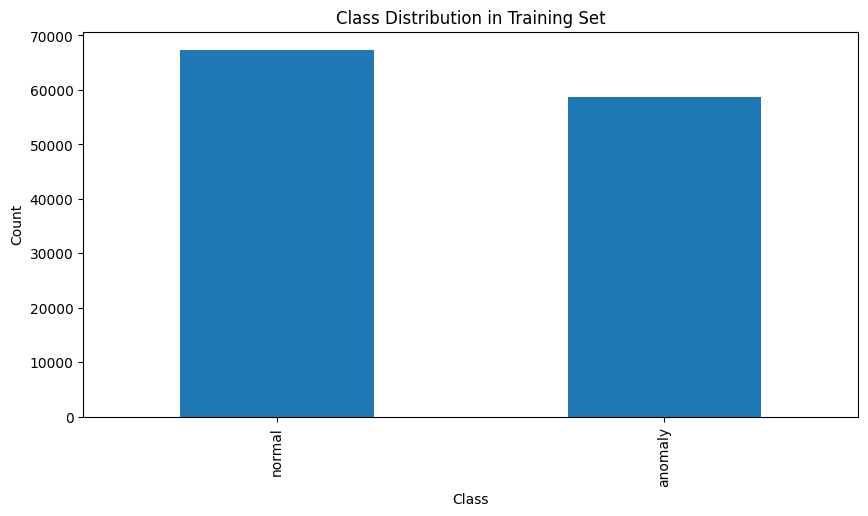

In [ ]:
# Data types and quick info
print("\n Data types summary:")
print(df_train.dtypes.value_counts())

# Summary of numeric columns
print("\n Statistical summary (numeric features):")
print(df_train.describe().T.head(10))

# Check for missing values
print("\n Missing values per column:")
print(df_train.isnull().sum().sort_values(ascending=False).head())

# Check unique values for key categorical columns
categorical_cols = ['protocol_type', 'service', 'flag']
for col in categorical_cols:
    if col in df_train.columns:
        print(f"\n Unique values in '{col}': {df_train[col].nunique()} → {df_train[col].unique()[:10]}")

# Class balance (target distribution)
print("\n Class distribution in training data:")
print(df_train['label'].value_counts())
print("\nClass distribution (%)")
print(round(df_train['label'].value_counts(normalize=True) * 100, 2))

#Visual class balance
df_train['label'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Class Distribution in Training Set')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()


In [ ]:
df_train.shape, df_test.shape


((125973, 42), (22544, 42))



## Feature Preparation and balancing

In [ ]:
# Verify categorical variable meanings
categorical_cols = ['protocol_type', 'service', 'flag']

for col in categorical_cols:
    print(f"--- {col} ---")
    print("Unique values:", df_train[col].unique()[:15])  # first 15 to keep it short
    print("Number of unique values:", df_train[col].nunique())
    print()

--- protocol_type ---
Unique values: ['tcp' 'udp' 'icmp']
Number of unique values: 3

--- service ---
Unique values: ['ftp_data' 'other' 'private' 'http' 'remote_job' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50']
Number of unique values: 70

--- flag ---
Unique values: ['SF' 'S0' 'REJ' 'RSTR' 'SH' 'RSTO' 'S1' 'RSTOS0' 'S3' 'S2' 'OTH']
Number of unique values: 11



In [ ]:
# Separate features (X) and target label (y)
X_train = df_train.drop('label', axis=1)
y_train = df_train['label']

X_test = df_test.drop('label', axis=1)
y_test = df_test['label']

In [ ]:
# One-hot encode categorical features
X_train_enc = pd.get_dummies(X_train, columns=['protocol_type', 'service', 'flag'])
X_test_enc = pd.get_dummies(X_test, columns=['protocol_type', 'service', 'flag'])

# Align columns between train and test
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='left', axis=1, fill_value=0)

print("Encoded train shape:", X_train_enc.shape)
print("Encoded test shape:", X_test_enc.shape)


Encoded train shape: (125973, 122)
Encoded test shape: (22544, 122)


In [ ]:
# Handle class imbalance using SMOTE
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_enc, y_train)

print("\nAfter SMOTE:")
print(y_train_bal.value_counts())


Before SMOTE:
label
normal     67343
anomaly    58630
Name: count, dtype: int64

After SMOTE:
label
normal     67343
anomaly    67343
Name: count, dtype: int64


## Data Scaling

1.   List item


In [ ]:
# Scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test_enc)


In [ ]:
#Train/test split (80/20)
from sklearn.model_selection import train_test_split

X = pd.concat([X_train_enc, X_test_enc])
y = pd.concat([y_train, y_test])

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
#Quick check with a simple model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=300)
model.fit(X_train_scaled, y_train_bal)
y_pred = model.predict(X_test_scaled)A

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

     anomaly       0.92      0.63      0.74     12833
      normal       0.65      0.92      0.76      9711

    accuracy                           0.75     22544
   macro avg       0.78      0.78      0.75     22544
weighted avg       0.80      0.75      0.75     22544



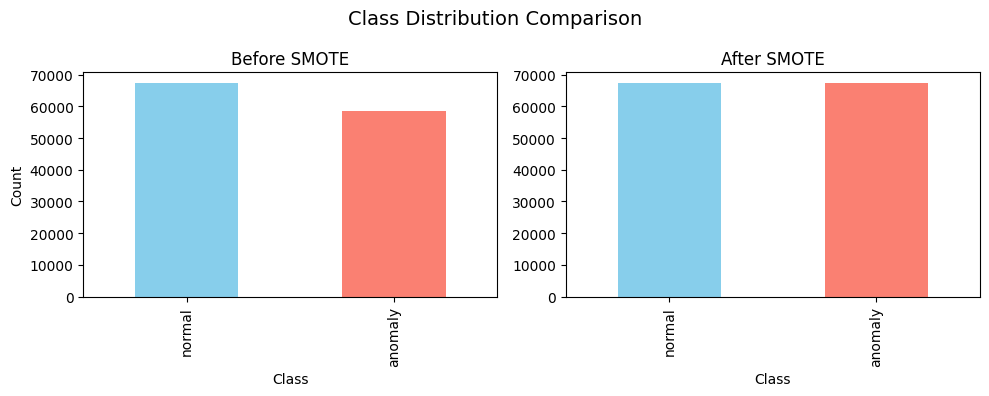

In [ ]:
#visual summary
import matplotlib.pyplot as plt

# Class distribution before and after SMOTE
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE
y_train.value_counts().plot(kind='bar', ax=ax[0], color=['skyblue', 'salmon'])
ax[0].set_title("Before SMOTE")
ax[0].set_xlabel("Class")
ax[0].set_ylabel("Count")

# After SMOTE
y_train_bal.value_counts().plot(kind='bar', ax=ax[1], color=['skyblue', 'salmon'])
ax[1].set_title("After SMOTE")
ax[1].set_xlabel("Class")

plt.suptitle("Class Distribution Comparison", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
#consistency check
print("X_train_bal shape:", X_train_bal.shape)
print("y_train_bal shape:", y_train_bal.shape)
print("X_test_scaled shape:", X_test_scaled.shape)
print("y_test shape:", y_test.shape)


X_train_bal shape: (134686, 122)
y_train_bal shape: (134686,)
X_test_scaled shape: (22544, 122)
y_test shape: (22544,)


## Baseline Implementation

### Decision Tree

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Decision Tree Classifier Report:
              precision    recall  f1-score   support

     anomaly       0.87      0.67      0.75     12833
      normal       0.66      0.86      0.75      9711

    accuracy                           0.75     22544
   macro avg       0.76      0.77      0.75     22544
weighted avg       0.78      0.75      0.75     22544



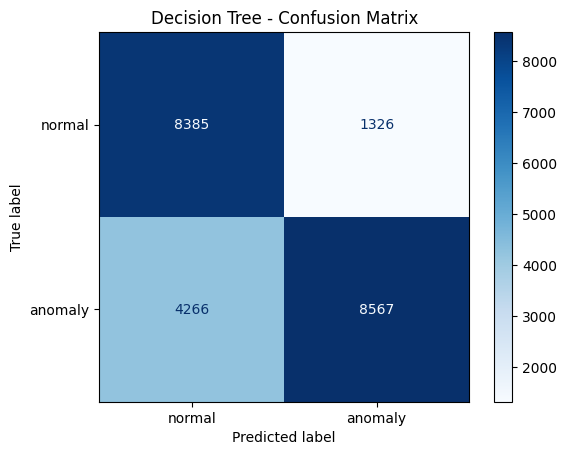

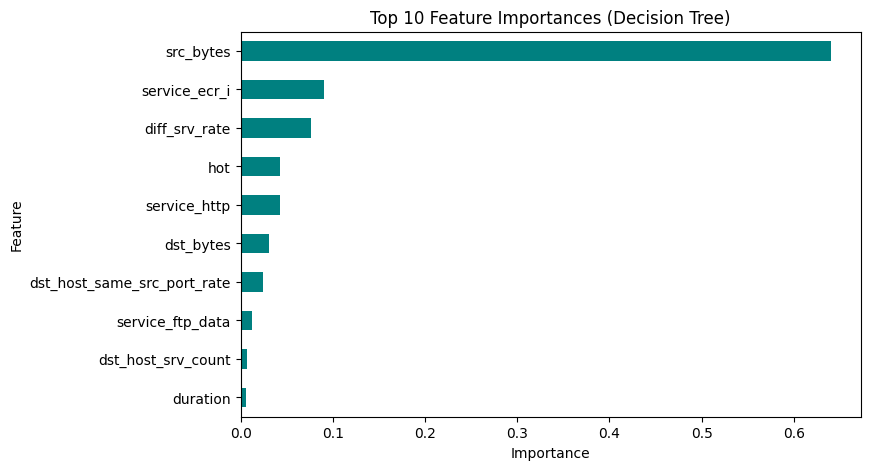

In [ ]:
# Import
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Creation and Training of the model
dt_model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=10,
    random_state=42
)

dt_model.fit(X_train_bal, y_train_bal)

# prediction on test data
y_pred_dt = dt_model.predict(X_test_scaled)

# Performance evaluation
print("Decision Tree Classifier Report:")
print(classification_report(y_test, y_pred_dt))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt, labels=['normal', 'anomaly'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['normal', 'anomaly'])
disp.plot(cmap='Blues')
plt.title("Decision Tree - Confusion Matrix")
plt.show()

# Feature Importance
importances = pd.Series(dt_model.feature_importances_, index=X_train_bal.columns)
importances = importances.sort_values(ascending=False)[:10]  # top 10 features

plt.figure(figsize=(8,5))
importances.plot(kind='barh', color='teal')
plt.title("Top 10 Feature Importances (Decision Tree)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()


### Random Forest

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Random Forest Classifier Report:
              precision    recall  f1-score   support

     anomaly       0.89      0.69      0.77     12833
      normal       0.68      0.89      0.77      9711

    accuracy                           0.77     22544
   macro avg       0.79      0.79      0.77     22544
weighted avg       0.80      0.77      0.77     22544



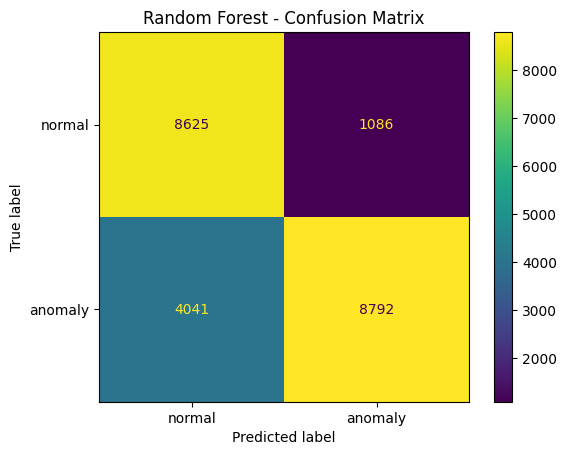

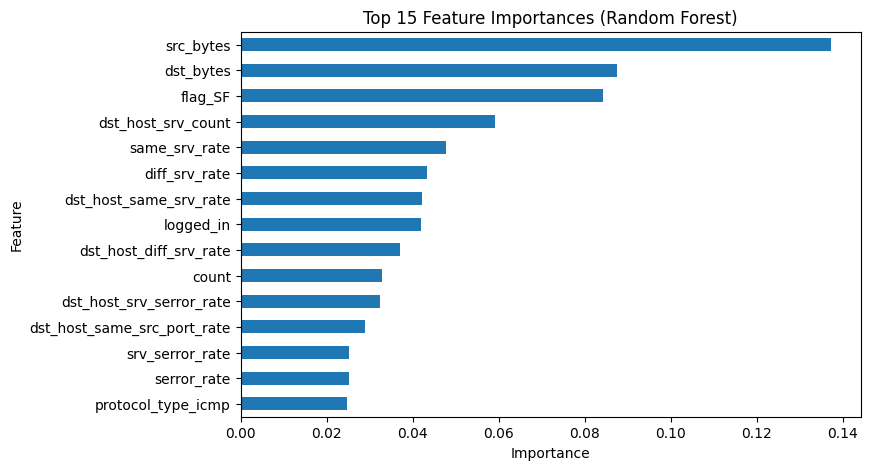

In [ ]:
#Import
from sklearn.ensemble import RandomForestClassifier

# Base model
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# Training
rf_model.fit(X_train_bal, y_train_bal)

# Prediction
y_pred_rf = rf_model.predict(X_test_scaled)

# Classification report
print("Random Forest Classifier Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf, labels=['normal', 'anomaly'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['normal', 'anomaly'])
disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

# Top 15 most important features
importances = pd.Series(rf_model.feature_importances_, index=X_train_bal.columns).sort_values(ascending=False)[:15]
plt.figure(figsize=(8,5))
importances.plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

### SVM

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


 SVM Classifier Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

     anomaly       0.00      0.00      0.00     12833
      normal       0.43      1.00      0.60      9711

    accuracy                           0.43     22544
   macro avg       0.22      0.50      0.30     22544
weighted avg       0.19      0.43      0.26     22544



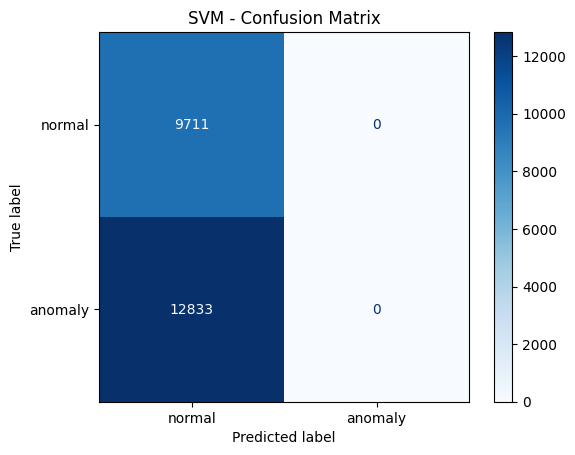

In [ ]:
#Import
from sklearn.svm import SVC

# Modèle
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    random_state=42,
    cache_size=1000,  # Increase cache for faster computation
    tol=1e-2,         # Increase tolerance (default 1e-3, faster convergence)
    max_iter=1000
)

svm_model.fit(X_train_bal, y_train_bal)

# Prédiction sur le test set
y_pred_svm = svm_model.predict(X_test_scaled)

# Rapport de classification
print(" SVM Classifier Report:")
print(classification_report(y_test, y_pred_svm))

# Matrice de confusion
cm = confusion_matrix(y_test, y_pred_svm, labels=['normal', 'anomaly'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['normal', 'anomaly'])
disp.plot(cmap='Blues')
plt.title("SVM - Confusion Matrix")
plt.show()

Apply cross-validation to check overfitting

In [ ]:
#Import
from sklearn.model_selection import cross_val_score
import numpy as np

# 5-fold cross-validation
print(" Validation croisée (5 folds) sur le modèle SVM...")


# On évalue avec la métrique F1-score (plus pertinente que accuracy ici)
cv_scores = cross_val_score(
    svm_model,
    X_train_bal,
    y_train_bal,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

print("\nRésultats de la validation croisée (F1-score macro) :")
print("Scores par pli :", np.round(cv_scores, 4))
print("Moyenne :", round(cv_scores.mean(), 4))
print("Écart-type :", round(cv_scores.std(), 4))

 Validation croisée (5 folds) sur le modèle SVM...

Résultats de la validation croisée (F1-score macro) :
Scores par pli : [0.3346 0.3333 0.3333 0.3333 0.3333]
Moyenne : 0.3336
Écart-type : 0.0005


# Model Tuning

### Decision Tree Hyperparameters Tuning


 Starting hyperparameter search for Decision Tree...
Fitting 5 folds for each of 48 candidates, totalling 240 fits
 Search completed in 4.26 minutes

RESULTS - DECISION TREE (GridSearchCV)
Best parameters found:
  • criterion: gini
  • max_depth: None
  • max_features: None
  • min_samples_leaf: 1
  • min_samples_split: 2

Best F1-macro score (CV): 0.9987

 Performance on test set with optimized hyperparameters:


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

     anomaly       0.80      0.71      0.75     12833
      normal       0.66      0.76      0.71      9711

    accuracy                           0.73     22544
   macro avg       0.73      0.74      0.73     22544
weighted avg       0.74      0.73      0.73     22544



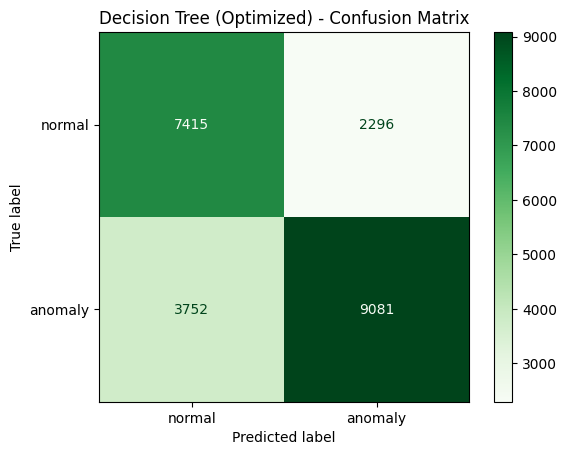


 Top 10 parameter combinations (Decision Tree):
                                                                                                           params  mean_test_score  std_test_score
    {'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}         0.998730        0.000129
      {'criterion': 'gini', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}         0.998641        0.000121
   {'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10}         0.998545        0.000181
     {'criterion': 'gini', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10}         0.998471        0.000221
   {'criterion': 'entropy', 'max_depth': 20, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}         0.998456        0.000263
 {'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'm

In [ ]:
""" Optimizing hyperparameters to improve model performance
using GridSearchCV and RandomizedSearchCV."""

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import randint, uniform
import numpy as np
import time

# Define the parameter grid to test
param_grid_dt = {
    'criterion': ['gini', 'entropy'],


    'max_depth': [10, 20, None],
    'min_samples_split': [2, 10],
    'min_samples_leaf': [1, 4],
    'max_features': ['sqrt', None]
    ## juste pour executer plus vite à suppr après

    #'max_depth': [5, 10, 15, 20, 25, None],
    #'min_samples_split': [2, 5, 10, 20],
    #'min_samples_leaf': [1, 2, 4, 8],
    #'max_features': ['sqrt', 'log2', None]
}

# Initialize GridSearchCV
grid_dt = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_dt,
    cv=5, # 5-fold cross-validation
    scoring='f1_macro', # for imbalanced data
    n_jobs=-1, #use of all available processors
    verbose=2
)

print(" Starting hyperparameter search for Decision Tree...")
start_time = time.time()

# Training with GridSearchCV
grid_dt.fit(X_train_bal, y_train_bal)

elapsed_time = time.time() - start_time
print(f" Search completed in {elapsed_time/60:.2f} minutes\n")


# Display the best parameters
print("="*60)
print("RESULTS - DECISION TREE (GridSearchCV)")
print("="*60)
print(f"Best parameters found:")
for param, value in grid_dt.best_params_.items():
    print(f"  • {param}: {value}")
print(f"\nBest F1-macro score (CV): {grid_dt.best_score_:.4f}")
print("="*60)

# Train the optimized model and evaluate on test set
best_dt_model = grid_dt.best_estimator_
y_pred_dt_tuned = best_dt_model.predict(X_test_scaled)

print("\n Performance on test set with optimized hyperparameters:")
print(classification_report(y_test, y_pred_dt_tuned))

# Confusion matrix for the optimized model
cm_dt = confusion_matrix(y_test, y_pred_dt_tuned, labels=['normal', 'anomaly'])
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['normal', 'anomaly'])
disp_dt.plot(cmap='Greens')
plt.title("Decision Tree (Optimized) - Confusion Matrix")
plt.show()

# Comparison of CV scores between all tested parameters (Top 10)
cv_results_dt = pd.DataFrame(grid_dt.cv_results_)
top_10_dt = cv_results_dt.nlargest(10, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
print("\n Top 10 parameter combinations (Decision Tree):")
print(top_10_dt.to_string(index=False))


### Random Forest Hyperparameter Tuning


 Starting random search for Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
 Search completed in 14.69 minutes

RESULTS - RANDOM FOREST (RandomizedSearchCV)
Best parameters found:
  • bootstrap: True
  • criterion: entropy
  • max_depth: None
  • max_features: log2
  • min_samples_leaf: 1
  • min_samples_split: 3
  • n_estimators: 200

Best F1-macro score (CV): 0.9989


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(



 Performance on test set with optimized hyperparameters:
              precision    recall  f1-score   support

     anomaly       0.90      0.65      0.76     12833
      normal       0.67      0.91      0.77      9711

    accuracy                           0.76     22544
   macro avg       0.79      0.78      0.76     22544
weighted avg       0.80      0.76      0.76     22544



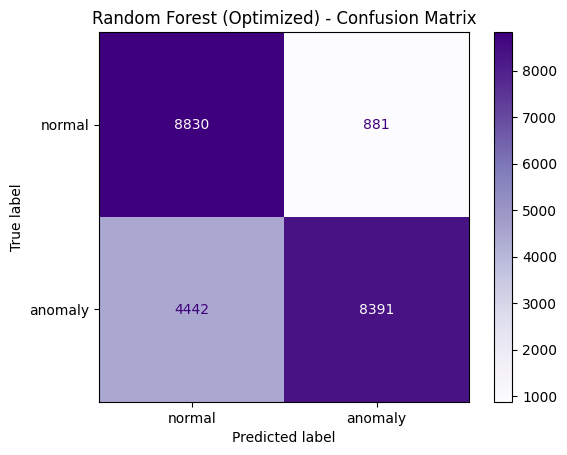


 Top 10 parameter combinations (Random Forest):
                                                                                                                                                    params  mean_test_score  std_test_score
{'bootstrap': True, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 200}         0.998857        0.000274
  {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 30, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 100}         0.998797        0.000253
{'bootstrap': True, 'criterion': 'entropy', 'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 8, 'n_estimators': 300}         0.998597        0.000253
  {'bootstrap': True, 'criterion': 'entropy', 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 200}         0.998456        0.000283
  {'bootstr

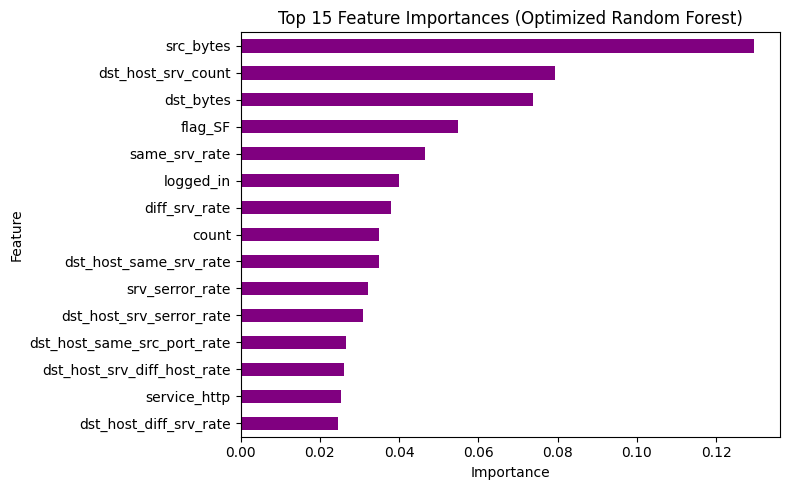

In [ ]:
# RandomizedSearchCV is preferred here because the search space is very large
param_dist_rf = {
    #'n_estimators': [100, 200, 300, 400, 500],
    #'max_depth': [10, 20, 30, 40, 50, None],
    #'min_samples_split': randint(2, 20),
    #'min_samples_leaf': randint(1, 10),
    #'max_features': ['sqrt', 'log2', None],
    #'bootstrap': [True, False],
    #'criterion': ['gini', 'entropy']

    'n_estimators': [100, 200, 300],  # Reduced from 5 options
    'max_depth': [20, 30, None],  # Reduced from 6 options
    'min_samples_split': randint(2, 10),  # Reduced range
    'min_samples_leaf': randint(1, 5),  # Reduced range
    'max_features': ['sqrt', 'log2'],  # Removed None option
    'bootstrap': [True],  # Fixed to True
    'criterion': ['entropy']  # Fixed to entropy
}

random_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_distributions=param_dist_rf,
    #n_iter=50,  # number of combinations to test
    n_iter=20,
    #cv=5,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

print("\n Starting random search for Random Forest...")
start_time = time.time()

# Training with RandomizedSearchCV
random_rf.fit(X_train_bal, y_train_bal)

elapsed_time = time.time() - start_time
print(f" Search completed in {elapsed_time/60:.2f} minutes\n")

# Display the best parameters
print("="*60)
print("RESULTS - RANDOM FOREST (RandomizedSearchCV)")
print("="*60)
print(f"Best parameters found:")
for param, value in random_rf.best_params_.items():
    print(f"  • {param}: {value}")
print(f"\nBest F1-macro score (CV): {random_rf.best_score_:.4f}")
print("="*60)

# Train the optimized model and evaluate on test set
best_rf_model = random_rf.best_estimator_
y_pred_rf_tuned = best_rf_model.predict(X_test_scaled)

print("\n Performance on test set with optimized hyperparameters:")
print(classification_report(y_test, y_pred_rf_tuned))

# Confusion matrix for the optimized model
cm_rf = confusion_matrix(y_test, y_pred_rf_tuned, labels=['normal', 'anomaly'])
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['normal', 'anomaly'])
disp_rf.plot(cmap='Purples')
plt.title("Random Forest (Optimized) - Confusion Matrix")
plt.show()

# Top 10 tested combinations
cv_results_rf = pd.DataFrame(random_rf.cv_results_)
top_10_rf = cv_results_rf.nlargest(10, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
print("\n Top 10 parameter combinations (Random Forest):")
print(top_10_rf.to_string(index=False))

# Feature importance of the optimized model
importances_rf_tuned = pd.Series(
    best_rf_model.feature_importances_,
    index=X_train_bal.columns
).sort_values(ascending=False)[:15]

plt.figure(figsize=(8,5))
importances_rf_tuned.plot(kind='barh', color='purple')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Optimized Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### SVM Hyperparameter Tuning


 Starting hyperparameter search for SVM...
Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


 Search completed in 28.49 minutes

 RESULTS - SVM (GridSearchCV)
Best parameters found:
  • C: 10
  • gamma: 0.01
  • kernel: rbf

Best F1-macro score (CV): 0.9746


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(



 Performance on test set with optimized hyperparameters:
              precision    recall  f1-score   support

     anomaly       0.99      0.15      0.26     12833
      normal       0.47      1.00      0.64      9711

    accuracy                           0.51     22544
   macro avg       0.73      0.57      0.45     22544
weighted avg       0.76      0.51      0.42     22544



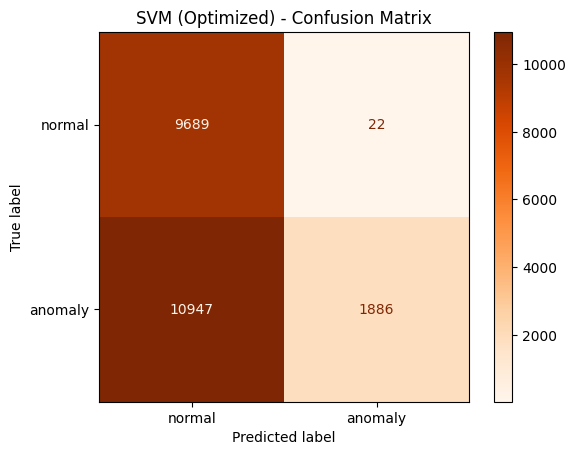


 Top 10 parameter combinations (SVM):
                                      params  mean_test_score  std_test_score
   {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}         0.974595        0.001969
    {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}         0.970093        0.002343
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}         0.440677        0.134241
 {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}         0.385931        0.068561


In [ ]:
# C controls the trade-off between wide margin and correct classification
# gamma defines the influence of each training point
#à suppr:
X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train_bal, y_train_bal,
    train_size=0.2,  # Use only 20%
    random_state=42,
    stratify=y_train_bal
)

param_grid_svm = {
    #'C': [0.1, 1, 10, 100],
    #'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    #'kernel': ['rbf']

    'C': [1, 10],
    'gamma': ['scale', 0.01],
    'kernel': ['rbf']
}

# Initialize GridSearchCV for SVM
grid_svm = GridSearchCV(
    estimator=SVC(random_state=42, class_weight='balanced'),
    param_grid=param_grid_svm,
    #cv=5,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

print("\n Starting hyperparameter search for SVM...")
start_time = time.time()

# Training with GridSearchCV
#grid_svm.fit(X_train_bal, y_train_bal)
grid_svm.fit(X_train_svm, y_train_svm)


elapsed_time = time.time() - start_time
print(f" Search completed in {elapsed_time/60:.2f} minutes\n")

# Display the best parameters
print("="*60)
print(" RESULTS - SVM (GridSearchCV)")
print("="*60)
print(f"Best parameters found:")
for param, value in grid_svm.best_params_.items():
    print(f"  • {param}: {value}")
print(f"\nBest F1-macro score (CV): {grid_svm.best_score_:.4f}")
print("="*60)

# Train the optimized model and evaluate on test set
best_svm_model = grid_svm.best_estimator_
y_pred_svm_tuned = best_svm_model.predict(X_test_scaled)

print("\n Performance on test set with optimized hyperparameters:")
print(classification_report(y_test, y_pred_svm_tuned))


# Confusion matrix for the optimized model
cm_svm = confusion_matrix(y_test, y_pred_svm_tuned, labels=['normal', 'anomaly'])
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['normal', 'anomaly'])
disp_svm.plot(cmap='Oranges')
plt.title("SVM (Optimized) - Confusion Matrix")
plt.show()

# Top 10 tested combinations
cv_results_svm = pd.DataFrame(grid_svm.cv_results_)
top_10_svm = cv_results_svm.nlargest(10, 'mean_test_score')[['params', 'mean_test_score', 'std_test_score']]
print("\n Top 10 parameter combinations (SVM):")
print(top_10_svm.to_string(index=False))

### Final Model Comparison

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



 COMPARATIVE TABLE - BEFORE vs AFTER OPTIMIZATION
                    Model  Accuracy  Precision  Recall  F1-Score  F1-Macro
     Decision Tree (Base)    0.7520     0.8660  0.6676    0.7539    0.7519
     Random Forest (Base)    0.7726     0.8901  0.6851    0.7743    0.7726
               SVM (Base)    0.4308     0.0000  0.0000    0.0000    0.3011
Decision Tree (Optimized)    0.7317     0.7982  0.7076    0.7502    0.7303
Random Forest (Optimized)    0.7639     0.9050  0.6539    0.7592    0.7638
          SVM (Optimized)    0.5134     0.9885  0.1470    0.2559    0.4472


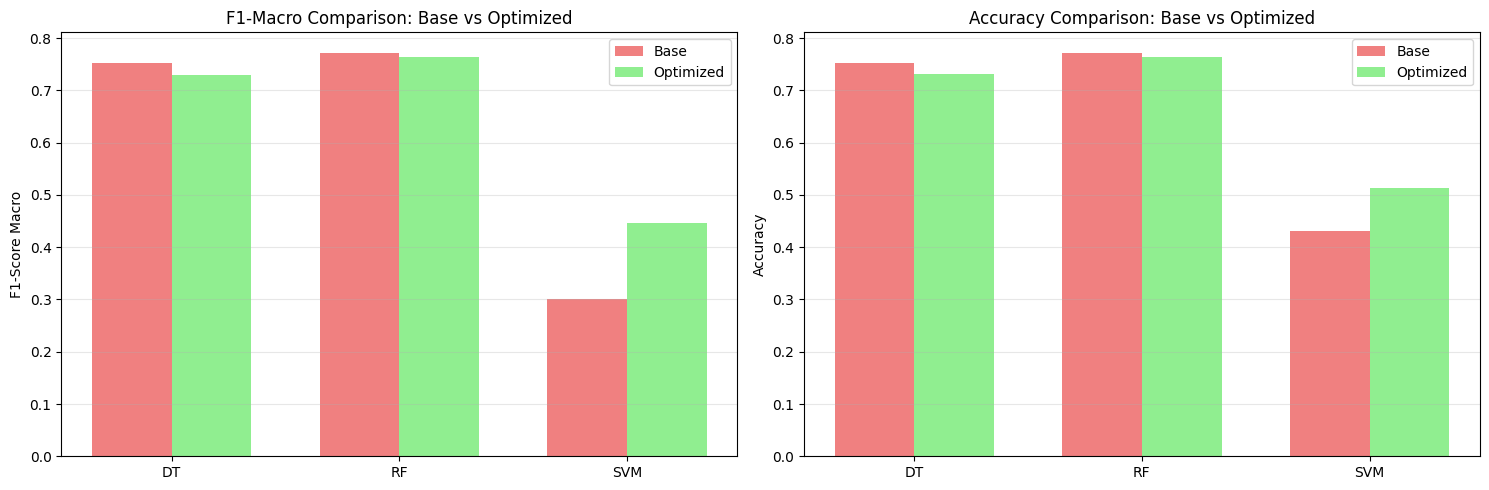


 Saving best parameters...

 SUMMARY OF BEST HYPERPARAMETERS

Decision Tree:
  • criterion: gini
  • max_depth: None
  • max_features: None
  • min_samples_leaf: 1
  • min_samples_split: 2

Random Forest:
  • bootstrap: True
  • criterion: entropy
  • max_depth: None
  • max_features: log2
  • min_samples_leaf: 1
  • min_samples_split: 3
  • n_estimators: 200

SVM:
  • C: 10
  • gamma: 0.01
  • kernel: rbf


In [ ]:
# Create a dictionary with all results
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Function to calculate all metrics
def calculate_metrics(y_true, y_pred, model_name):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label='anomaly'),
        'Recall': recall_score(y_true, y_pred, pos_label='anomaly'),
        'F1-Score': f1_score(y_true, y_pred, pos_label='anomaly'),
        'F1-Macro': f1_score(y_true, y_pred, average='macro')
    }

# Calculate metrics for all models
results = []

# Base models (before tuning)
results.append(calculate_metrics(y_test, y_pred_dt, 'Decision Tree (Base)'))
results.append(calculate_metrics(y_test, y_pred_rf, 'Random Forest (Base)'))
results.append(calculate_metrics(y_test, y_pred_svm, 'SVM (Base)'))

# Optimized models (after tuning)
results.append(calculate_metrics(y_test, y_pred_dt_tuned, 'Decision Tree (Optimized)'))
results.append(calculate_metrics(y_test, y_pred_rf_tuned, 'Random Forest (Optimized)'))
results.append(calculate_metrics(y_test, y_pred_svm_tuned, 'SVM (Optimized)'))

# Create a DataFrame for comparison
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.round(4)

print("\n" + "="*80)
print(" COMPARATIVE TABLE - BEFORE vs AFTER OPTIMIZATION")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Comparative visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Chart 1: F1-Macro Comparison
models = ['DT', 'RF', 'SVM']
base_scores = [
    f1_score(y_test, y_pred_dt, average='macro'),
    f1_score(y_test, y_pred_rf, average='macro'),
    f1_score(y_test, y_pred_svm, average='macro')
]
tuned_scores = [
    f1_score(y_test, y_pred_dt_tuned, average='macro'),
    f1_score(y_test, y_pred_rf_tuned, average='macro'),
    f1_score(y_test, y_pred_svm_tuned, average='macro')
]

x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, base_scores, width, label='Base', color='lightcoral')
axes[0].bar(x + width/2, tuned_scores, width, label='Optimized', color='lightgreen')
axes[0].set_ylabel('F1-Score Macro')
axes[0].set_title('F1-Macro Comparison: Base vs Optimized')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Chart 2: Accuracy Comparison
base_acc = [
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_svm)
]
tuned_acc = [
    accuracy_score(y_test, y_pred_dt_tuned),
    accuracy_score(y_test, y_pred_rf_tuned),
    accuracy_score(y_test, y_pred_svm_tuned)
]

axes[1].bar(x - width/2, base_acc, width, label='Base', color='lightcoral')
axes[1].bar(x + width/2, tuned_acc, width, label='Optimized', color='lightgreen')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy Comparison: Base vs Optimized')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Save the best models and parameters
print("\n Saving best parameters...")
best_params_summary = {
    'Decision Tree': grid_dt.best_params_,
    'Random Forest': random_rf.best_params_,
    'SVM': grid_svm.best_params_
}

# Display final summary
print("\n" + "="*80)
print(" SUMMARY OF BEST HYPERPARAMETERS")
print("="*80)
for model_name, params in best_params_summary.items():
    print(f"\n{model_name}:")
    for param, value in params.items():
        print(f"  • {param}: {value}")
print("="*80)



## ROC-AUC Analysis

In [ ]:
#Measure model discrimination ability using ROC curves

from sklearn.metrics import roc_curve, auc, roc_auc_score

# Get probability predictions for anomaly class
y_test_binary = (y_test == 'anomaly')

# Calculate ROC-AUC scores
print("="*60)
print("ROC-AUC SCORES")
print("="*60)

# Base models
auc_dt_base = roc_auc_score(y_test_binary, dt_model.predict_proba(X_test_scaled)[:, 1])
auc_rf_base = roc_auc_score(y_test_binary, rf_model.predict_proba(X_test_scaled)[:, 1])
auc_svm_base = roc_auc_score(y_test_binary, svm_model.decision_function(X_test_scaled))

# Optimized models
auc_dt_opt = roc_auc_score(y_test_binary, best_dt_model.predict_proba(X_test_scaled)[:, 1])
auc_rf_opt = roc_auc_score(y_test_binary, best_rf_model.predict_proba(X_test_scaled)[:, 1])
auc_svm_opt = roc_auc_score(y_test_binary, best_svm_model.decision_function(X_test_scaled))

print(f"Decision Tree: {auc_dt_base:.4f} → {auc_dt_opt:.4f}")
print(f"Random Forest: {auc_rf_base:.4f} → {auc_rf_opt:.4f}")
print(f"SVM: {auc_svm_base:.4f} → {auc_svm_opt:.4f}")
print("="*60)

# Plot ROC curves
plt.figure(figsize=(10, 7))

# Optimized models
fpr_dt, tpr_dt, _ = roc_curve(y_test_binary, best_dt_model.predict_proba(X_test_scaled)[:, 1])
fpr_rf, tpr_rf, _ = roc_curve(y_test_binary, best_rf_model.predict_proba(X_test_scaled)[:, 1])
fpr_svm, tpr_svm, _ = roc_curve(y_test_binary, best_svm_model.decision_function(X_test_scaled))

plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt_opt:.3f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf_opt:.3f})', linewidth=2)
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc_svm_opt:.3f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Optimized Models')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()


In [ ]:
from sklearn.ensemble import BaggingClassifier, VotingClassifier, StackingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import time

print("="*80)
print("ENSEMBLE LEARNING FOR INTRUSION DETECTION SYSTEM")
print("="*80)

ENSEMBLE LEARNING FOR INTRUSION DETECTION SYSTEM


In [ ]:
# EXTRACT BEST MODELS FROM YOUR GRIDSEARCH RESULTS

best_dt_model = grid_dt.best_estimator_
best_rf_model = random_rf.best_estimator_
best_svm_model = grid_svm.best_estimator_

# Verify models are loaded
print(f"Decision Tree Model: {type(best_dt_model)}")
print(f"Random Forest Model: {type(best_rf_model)}")
print(f"SVM Model: {type(best_svm_model)}")


Bagging - Decision Tree

In [ ]:
print("\n" + "="*80)
print("1. BAGGING WITH DECISION TREE")
print("="*80)

bagging_dt = BaggingClassifier(
    estimator=best_dt_model,
    n_estimators=50,
    max_samples=0.8,
    max_features=0.8,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

start_time = time.time()
bagging_dt.fit(X_train_bal, y_train_bal)
training_time_dt = time.time() - start_time

start_time = time.time()
y_pred_bagging_dt = bagging_dt.predict(X_test_scaled)
inference_time_dt = time.time() - start_time

print(f"\nTraining Time: {training_time_dt:.2f} seconds")
print(f"Inference Time: {inference_time_dt:.4f} seconds")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bagging_dt))

cm_bagging_dt = confusion_matrix(y_test, y_pred_bagging_dt, labels=['normal', 'anomaly'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bagging_dt, display_labels=['normal', 'anomaly'])
disp.plot(cmap='Blues')
plt.title('Bagging Decision Tree - Confusion Matrix')
plt.show()

bagging_dt_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_bagging_dt),
    'Precision': precision_score(y_test, y_pred_bagging_dt, pos_label='anomaly'),
    'Recall': recall_score(y_test, y_pred_bagging_dt, pos_label='anomaly'),
    'F1-Score': f1_score(y_test, y_pred_bagging_dt, pos_label='anomaly'),
    'F1-Macro': f1_score(y_test, y_pred_bagging_dt, average='macro'),
    'Training Time': training_time_dt,
    'Inference Time': inference_time_dt
}

print(f"\n Bagging DT - F1-Macro: {bagging_dt_metrics['F1-Macro']:.4f}")


Bagging - SVM

In [ ]:
print("\n" + "="*80)
print("2. BAGGING WITH SVM")
print("="*80)

bagging_svm = BaggingClassifier(
    estimator=best_svm_model,
    n_estimators=30,
    max_samples=0.7,
    max_features=0.9,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

start_time = time.time()
bagging_svm.fit(X_train_bal, y_train_bal)
training_time_svm = time.time() - start_time

start_time = time.time()
y_pred_bagging_svm = bagging_svm.predict(X_test_scaled)
inference_time_svm = time.time() - start_time

print(f"\nTraining Time: {training_time_svm:.2f} seconds")
print(f"Inference Time: {inference_time_svm:.4f} seconds")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bagging_svm))

cm_bagging_svm = confusion_matrix(y_test, y_pred_bagging_svm, labels=['normal', 'anomaly'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_bagging_svm, display_labels=['normal', 'anomaly'])
disp.plot(cmap='Oranges')
plt.title('Bagging SVM - Confusion Matrix')
plt.show()

bagging_svm_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_bagging_svm),
    'Precision': precision_score(y_test, y_pred_bagging_svm, pos_label='anomaly'),
    'Recall': recall_score(y_test, y_pred_bagging_svm, pos_label='anomaly'),
    'F1-Score': f1_score(y_test, y_pred_bagging_svm, pos_label='anomaly'),
    'F1-Macro': f1_score(y_test, y_pred_bagging_svm, average='macro'),
    'Training Time': training_time_svm,
    'Inference Time': inference_time_svm
}

print(f"\n Bagging SVM - F1-Macro: {bagging_svm_metrics['F1-Macro']:.4f}")


Voting Classifier

In [ ]:
print("\n" + "="*80)
print("3. VOTING CLASSIFIER - SOFT VOTING")
print("="*80)

voting_clf = VotingClassifier(
    estimators=[
        ('random_forest', best_rf_model),
        ('decision_tree', best_dt_model),
        ('svm', best_svm_model)
    ],
    voting='soft',
    weights=[3, 1, 2],
    n_jobs=-1
)

start_time = time.time()
voting_clf.fit(X_train_bal, y_train_bal)
training_time_voting = time.time() - start_time

start_time = time.time()
y_pred_voting = voting_clf.predict(X_test_scaled)
inference_time_voting = time.time() - start_time

print(f"\nTraining Time: {training_time_voting:.2f} seconds")
print(f"Inference Time: {inference_time_voting:.4f} seconds")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_voting))

cm_voting = confusion_matrix(y_test, y_pred_voting, labels=['normal', 'anomaly'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_voting, display_labels=['normal', 'anomaly'])
disp.plot(cmap='Greens')
plt.title('Voting Classifier - Confusion Matrix')
plt.show()

voting_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_voting),
    'Precision': precision_score(y_test, y_pred_voting, pos_label='anomaly'),
    'Recall': recall_score(y_test, y_pred_voting, pos_label='anomaly'),
    'F1-Score': f1_score(y_test, y_pred_voting, pos_label='anomaly'),
    'F1-Macro': f1_score(y_test, y_pred_voting, average='macro'),
    'Training Time': training_time_voting,
    'Inference Time': inference_time_voting
}

print(f"\n Voting Classifier - F1-Macro: {voting_metrics['F1-Macro']:.4f}")


 Stacking Classifier

In [ ]:
print("\n" + "="*80)
print("4. STACKING CLASSIFIER")
print("="*80)

from sklearn.linear_model import LogisticRegression

stacking_clf = StackingClassifier(
    estimators=[
        ('rf', best_rf_model),
        ('dt', best_dt_model),
        ('svm', best_svm_model)
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3,
    n_jobs=-1
)

start_time = time.time()
stacking_clf.fit(X_train_bal, y_train_bal)
training_time_stacking = time.time() - start_time

start_time = time.time()
y_pred_stacking = stacking_clf.predict(X_test_scaled)
inference_time_stacking = time.time() - start_time

print(f"\nTraining Time: {training_time_stacking:.2f} seconds")
print(f"Inference Time: {inference_time_stacking:.4f} seconds")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_stacking))

cm_stacking = confusion_matrix(y_test, y_pred_stacking, labels=['normal', 'anomaly'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_stacking, display_labels=['normal', 'anomaly'])
disp.plot(cmap='Purples')
plt.title('Stacking Classifier - Confusion Matrix')
plt.show()

stacking_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_stacking),
    'Precision': precision_score(y_test, y_pred_stacking, pos_label='anomaly'),
    'Recall': recall_score(y_test, y_pred_stacking, pos_label='anomaly'),
    'F1-Score': f1_score(y_test, y_pred_stacking, pos_label='anomaly'),
    'F1-Macro': f1_score(y_test, y_pred_stacking, average='macro'),
    'Training Time': training_time_stacking,
    'Inference Time': inference_time_stacking
}

print(f"\n Stacking Classifier - F1-Macro: {stacking_metrics['F1-Macro']:.4f}")


Visualization

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models = comparison_results['Model']
f1_scores = comparison_results['F1-Macro']

axes[0, 0].barh(models, f1_scores, color='steelblue')
axes[0, 0].set_xlabel('F1-Macro Score')
axes[0, 0].set_title('F1-Macro Score Comparison')
axes[0, 0].set_xlim([0, 1])
for i, v in enumerate(f1_scores):
    axes[0, 0].text(v + 0.01, i, f'{v:.4f}', va='center')

axes[0, 1].scatter(comparison_results['Accuracy'],
                   comparison_results['Precision'],
                   s=200, alpha=0.6, c=range(len(models)), cmap='viridis')
for i, txt in enumerate(models):
    axes[0, 1].annotate(txt,
                        (comparison_results['Accuracy'][i],
                         comparison_results['Precision'][i]),
                        fontsize=8, ha='center')
axes[0, 1].set_xlabel('Accuracy')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Accuracy vs Precision Trade-off')
axes[0, 1].grid(alpha=0.3)

axes[1, 0].bar(range(len(models)), comparison_results['Recall'],
               color='coral', alpha=0.7)
axes[1, 0].set_xticks(range(len(models)))
axes[1, 0].set_xticklabels(models, rotation=45, ha='right')
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_title('Recall Score Comparison')
axes[1, 0].grid(axis='y', alpha=0.3)

from math import pi

ensemble_models = ['Bagging + Decision Tree', 'Bagging + SVM',
                   'Voting Classifier', 'Stacking Classifier', 'Gradient Boosting']
ensemble_data = comparison_results[comparison_results['Model'].isin(ensemble_models)]

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Macro']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

ax = plt.subplot(2, 2, 4, projection='polar')
for idx, model in enumerate(ensemble_data['Model']):
    values = ensemble_data[ensemble_data['Model'] == model][categories].values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=model)
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_ylim(0, 1)
ax.set_title('Ensemble Models Performance', size=11, y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
ax.grid(True)

plt.tight_layout()
plt.show()